# Segmentación no supervisada de clientes Telco

Este notebook desarrolla un flujo completo de trabajo como ejemplo para el curso de Aprendizaje no Supervisado de la Especialización en Machine Learning. El ejemplo se construyó utilizando el dataset *IBM Telco Customer Churn*.

### Qué incluye el ejemplo:
1. Realiza una exploración inicial y detecta problemas de calidad de datos.
2. Analiza variables numéricas y categóricas mediante visualizaciones.
3. Identifica valores faltantes, variables irrelevantes y posibles valores atípicos.
4. Prepara variables mixtas para algoritmos basados en distancia.
5. Utiliza t-SNE como herramienta de inspección visual de la estructura de los datos.
6. Compara tres algoritmos de clustering:
   - K-Means
   - Clustering jerárquico aglomerativo
   - DBSCAN
7. Evalúa si la reducción de dimensionalidad mejora la estructura de los clusters:
   - PCA
   - Truncated SVD
   - Autoencoder
8. Compara las soluciones mediante métricas internas y, de forma secundaria, contra `Churn` como referencia externa.

`Churn` en el dataset es la variable objetivo, esta indica si un cliente dejó de contratar los servicios de la empresa durante el periodo observado, toma valores yes o no. En este ejemplo esta variable no se utiliza como variable de entrada para construir los clusters. Se reserva únicamente para interpretación posterior.

## 1. Importación de librerías y configuración

El notebook se puede ejecutar en Google Colab, se utiliza TensorFlow/Keras para construir el autoencoder.

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import sparse
from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

## 2. Carga del dataset

Cada fila representa un cliente y las columnas describen información demográfica, servicios contratados, antigüedad, facturación y abandono (`Churn`).

El archivo se descarga desde una copia pública del dataset original. Si la URL no estuviera disponible, se puede subir el CSV manualmente y sustituir `DATA_URL` por la ruta local.

In [5]:
DATA_URL = ("https://raw.githubusercontent.com/aiplanethub/Datasets/master/"
    "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df_raw = pd.read_csv(DATA_URL)
df = df_raw.copy()

print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(df.info())
display(df.head())

Dimensiones: 7,043 filas x 21 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Exploración inicial

En esta exploración inicial se revisa si hay duplicados en los datos, valores faltantes, y la cardinalidad de las variables.

In [6]:
print("\nDUPLICADOS COMPLETOS:", df.duplicated().sum())
print("customerID únicos:", df["customerID"].nunique(), "de", len(df))

print("\nRESUMEN GENERAL:")
display(df.describe(include='object').T)


DUPLICADOS COMPLETOS: 0
customerID únicos: 7043 de 7043

RESUMEN GENERAL:


,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


La función `isna()` detecta datos faltantes. Sin embargo, algunos CSV almacenan valores ausentes como cadenas vacías o espacios. Por eso conviene revisar también variables de tipo object con espacios.

In [7]:
missing_explicit = df.isna().sum().sort_values(ascending=False)
print("Faltantes explícitos detectados por isna():")
display(missing_explicit[missing_explicit > 0].to_frame("n_faltantes"))

object_cols_raw = df.select_dtypes(include="object").columns
blank_counts = {c: df[c].astype(str).str.strip().eq("").sum() for c in object_cols_raw}
blank_counts = pd.Series(blank_counts).sort_values(ascending=False)

print("Cadenas vacías o espacios en variables de texto:")
display(blank_counts[blank_counts > 0].to_frame("n_vacios"))

Faltantes explícitos detectados por isna():


,n_faltantes


Cadenas vacías o espacios en variables de texto:


,n_vacios
TotalCharges,11


### 3.2 Cardinalidad de las variables categóricas

Esta inspección ayuda a detectar identificadores, variables casi constantes y categorías que necesitarán codificación.

In [8]:
cat_summary = []
for c in object_cols_raw:
    cat_summary.append({
        "variable": c,
        "n_unicos": df[c].nunique(dropna=False),
        "ejemplos": list(df[c].drop_duplicates().astype(str).head(8))
    })

display(pd.DataFrame(cat_summary).sort_values("n_unicos", ascending=False))

,variable,n_unicos,ejemplos
0,customerID,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
16,TotalCharges,6531,"[29.85, 1889.5, 108.15, 1840.75, 151.65, 820.5..."
15,PaymentMethod,4,"[Electronic check, Mailed check, Bank transfer..."
13,Contract,3,"[Month-to-month, One year, Two year]"
5,MultipleLines,3,"[No phone service, No, Yes]"
8,OnlineBackup,3,"[Yes, No, No internet service]"
9,DeviceProtection,3,"[No, Yes, No internet service]"
10,TechSupport,3,"[No, Yes, No internet service]"
7,OnlineSecurity,3,"[No, Yes, No internet service]"
6,InternetService,3,"[DSL, Fiber optic, No]"


## 4. Limpieza de datos para continuar con la inspección

Antes de continuar con una exploración más detallada de las variables es necesario hacer una limipieza de los datos para evitar los problemas que pueden causar los datos faltantes y en especial para este dataset la variable TotalCharge que parece ser una variable numérica y no categórica. Se realizará limpieza de las siguientes variables:

1. `customerID` es un identificador contiene un valor único para cada ejemplo, por lo tanto no aportará ningún patrón de interés.
2. `TotalCharges` parece numérica, pero llega como texto porque contiene espacios.
3. `SeniorCitizen` está codificada como 0/1, pero conceptualmente es categórica.
4. Los faltantes de `TotalCharges` deben analizarse antes de imputar automáticamente.

In [9]:
# Convertimos espacios en NaN y luego intentamos convertir TotalCharges a número.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True), errors="coerce")
print("TotalCharges faltantes después de la conversión:", df["TotalCharges"].isna().sum())

display(df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

TotalCharges faltantes después de la conversión: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


### Imputación basada en contexto

Antes de usar media o mediana, comprobamos si los faltantes siguen una lógica de negocio. En este dataset clientes con `tenure = 0`, es decir, sin historial acumulado de cobros deberían tener TotalCharges = 0.

Primero se verifica esa condición. Si se cumple para todos los casos, imputa `TotalCharges = 0`; si no, utiliza la mediana.

In [10]:
mask_missing_total = df["TotalCharges"].isna()

if mask_missing_total.any() and df.loc[mask_missing_total, "tenure"].eq(0).all():
    df.loc[mask_missing_total, "TotalCharges"] = 0.0
    print("Imputación aplicada: TotalCharges = 0 para clientes con tenure = 0.")
elif mask_missing_total.any():
    mediana = df["TotalCharges"].median()
    df["TotalCharges"] = df["TotalCharges"].fillna(mediana)
    print(f"Imputación alternativa aplicada con mediana = {mediana:.2f}.")
else:
    print("No quedan faltantes en TotalCharges.")

Imputación aplicada: TotalCharges = 0 para clientes con tenure = 0.


### Conversión de SeniorCitizen de numérica a categórica

Esta conversión se hace porque conceptualmente `SeniorCitizenes` es una variable categórica binaria, no una magnitud numérica.

In [11]:
print(df["SeniorCitizen"].dtype)
print(df["SeniorCitizen"].unique())

int64
[0 1]


In [12]:
# SeniorCitizen se trata como categórica, no como magnitud numérica.
df["SeniorCitizen"] = df["SeniorCitizen"].replace({ 0: "No", 1: "Yes"})

In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 5. Análisis exploratorio visual

Separaremos variables numéricas y categóricas. Las visualizaciones no son un adorno: deben servir para decidir transformaciones posteriores.

In [14]:
TARGET = "Churn"
ID_COL = "customerID"

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols = [c for c in df.columns if c not in numeric_cols + [TARGET, ID_COL]]

print("Variables numéricas:", numeric_cols)
print("\nVariables categóricas:", categorical_cols)

Variables numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']

Variables categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 5.1 Histogramas y diagramas de caja de variables numéricas

Buscamos asimetría, concentraciones, escalas muy diferentes y posibles valores atípicos.

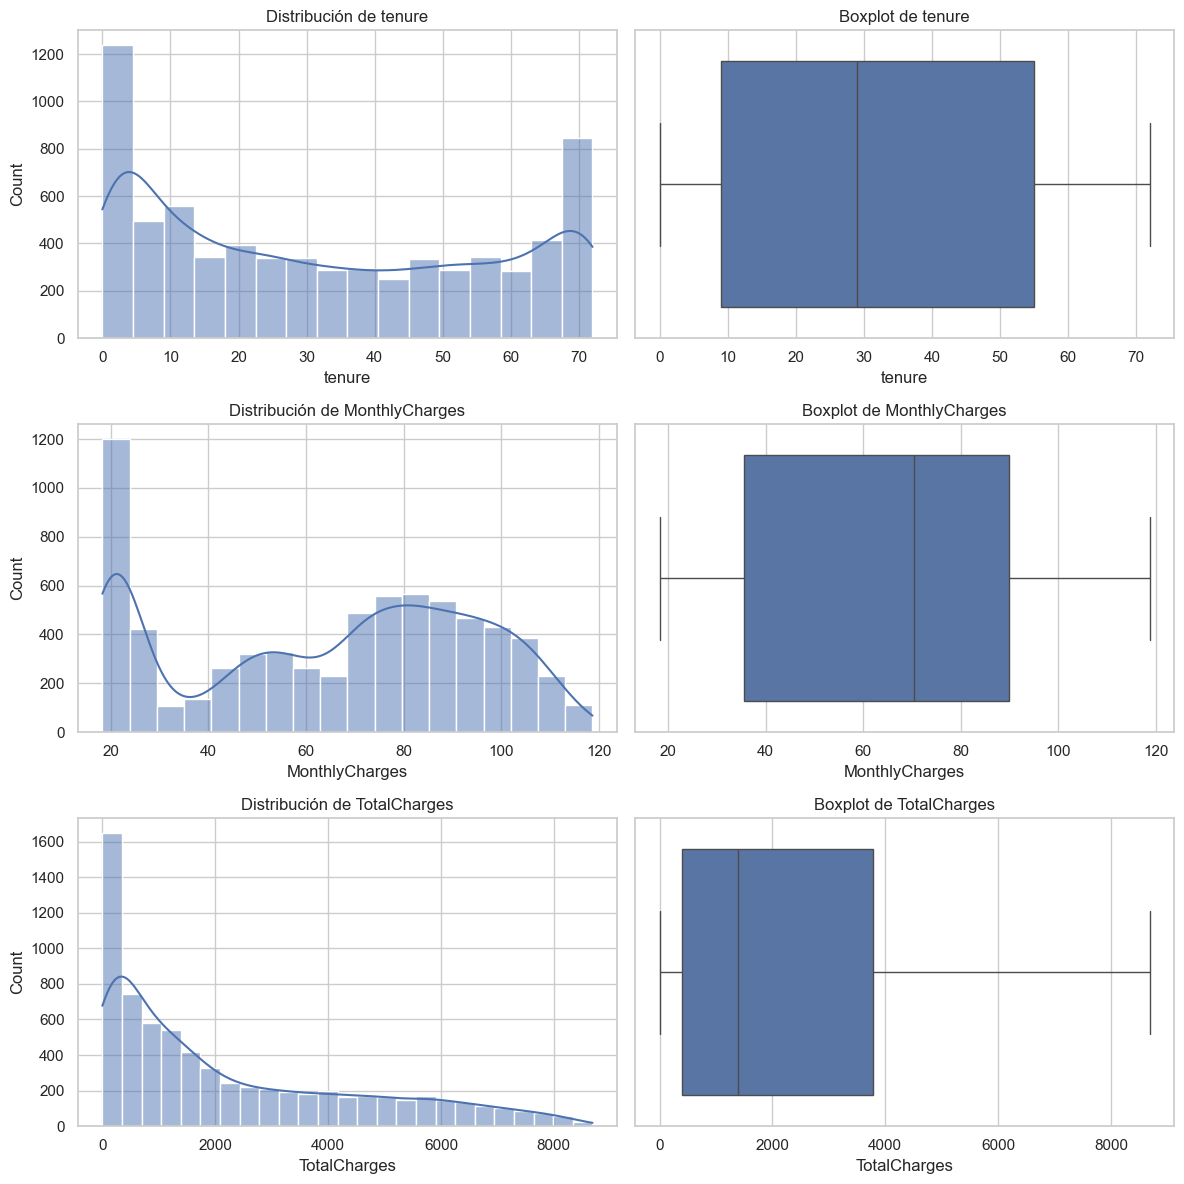

In [15]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 4 * len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribución de {col}")

    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

### 5.2 Diagramas de barras de variables categóricas

En lugar de dibujar todas las categorías en una sola figura, se muestran paneles para observar desbalance y categorías especiales como `No internet service` o `No phone service`.

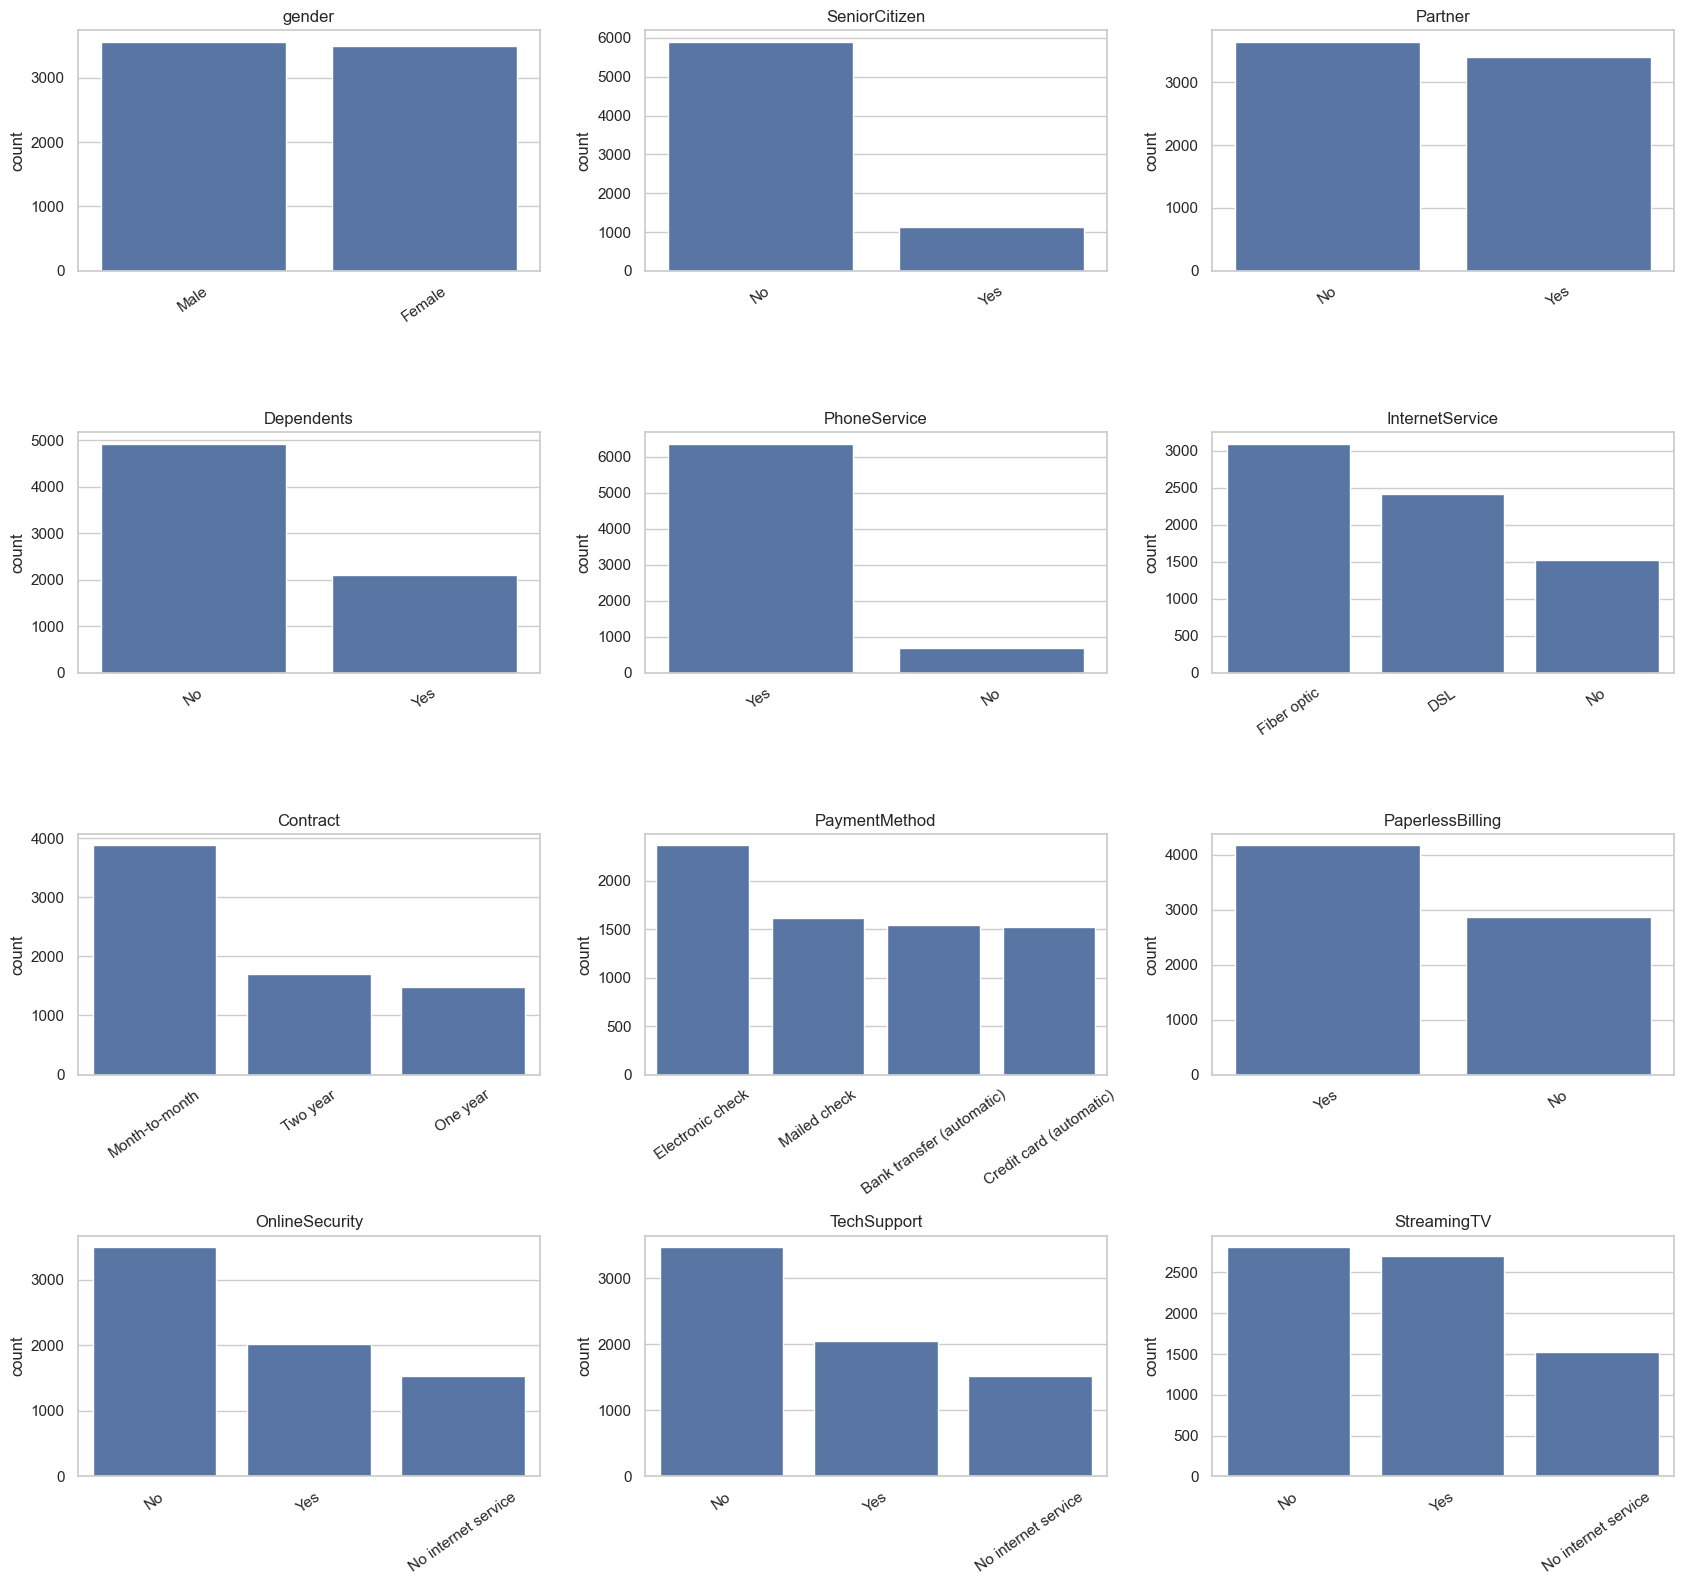

In [16]:
cols_to_plot = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "InternetService", "Contract", "PaymentMethod",
    "PaperlessBilling", "OnlineSecurity", "TechSupport", "StreamingTV"
]

ncols = 3
nrows = int(np.ceil(len(cols_to_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, cols_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=35)
    ax.set_xlabel("")

for ax in axes[len(cols_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Análisis de correlación y asociación

### 6.1 Correlación de Spearman entre variables numéricas

Dado que las variables numéricas presentan distribuciones asimétricas y posibles valores extremos, y no se desea asumir una relación estrictamente lineal entre ellas, se utiliza la correlación de Spearman. Este coeficiente se basa en los rangos de las observaciones y permite detectar relaciones monótonas entre las variables.

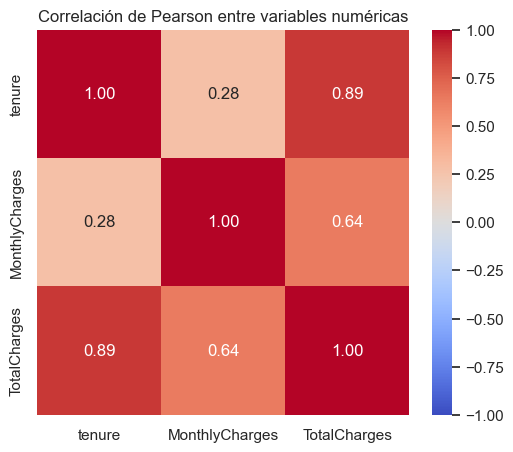

In [17]:
corr_num = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(6, 5))
sns.heatmap(corr_num, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación de Pearson entre variables numéricas")
plt.show()

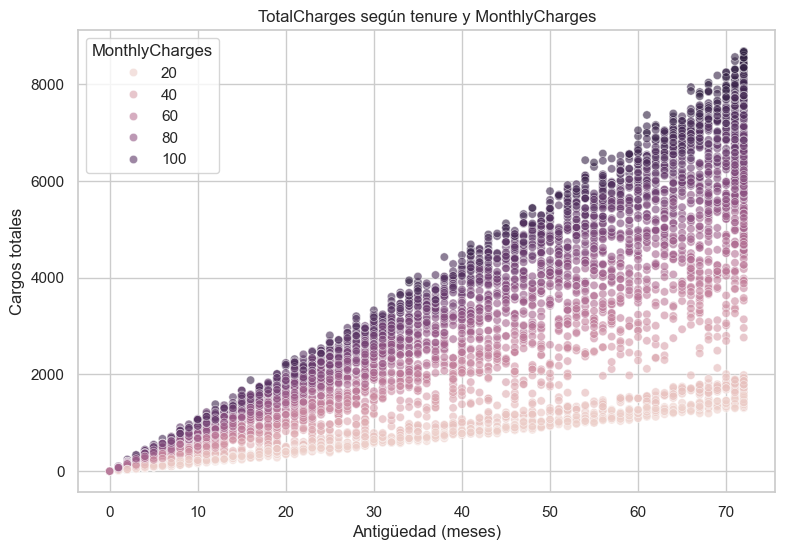

In [18]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tenure",
    y="TotalCharges",
    hue="MonthlyCharges",
    alpha=0.6
)

plt.title("TotalCharges según tenure y MonthlyCharges")
plt.xlabel("Antigüedad (meses)")
plt.ylabel("Cargos totales")
plt.show()

Se observa que `tenure` y `TotalCharges` tienen una correlación alta de 0.89, esto tiene sentido porque los cargos totales se acumulan con el tiempo Para una misma antigüedad, los cargos totales varían considerablemente debido a diferencias en `MonthlyCharges`. Por tanto, las variables aportan información parcialmente redundante, pero no equivalente. Se conservarán inicialmente para evaluar posteriormente si técnicas de reducción dimensional, como PCA, pueden representar esta estructura de manera más compacta.

### 6.2 Asociación entre variables categóricas con V de Cramér

Para variables categóricas es más apropiado utilizar una medida basada en chi-cuadrado, como _V de Cramér_, que toma valores próximos a 0 cuando la asociación es débil y próximos a 1 cuando es fuerte.

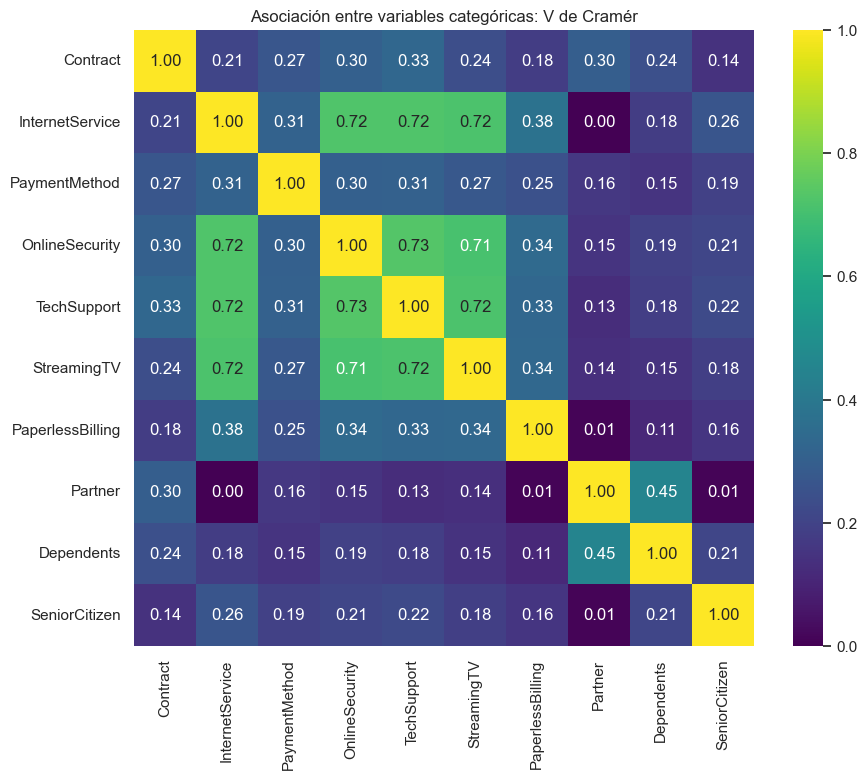

In [19]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    if n <= 1 or min(r - 1, k - 1) == 0:
        return 0.0
    phi2 = chi2 / n
    # Corrección de sesgo de Bergsma/Wicher.
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0

cat_for_assoc = [
    "Contract", "InternetService", "PaymentMethod", "OnlineSecurity",
    "TechSupport", "StreamingTV", "PaperlessBilling", "Partner",
    "Dependents", "SeniorCitizen"
]

cramer = pd.DataFrame(index=cat_for_assoc, columns=cat_for_assoc, dtype=float)
for a in cat_for_assoc:
    for b in cat_for_assoc:
        cramer.loc[a, b] = cramers_v(df[a], df[b])

plt.figure(figsize=(10, 8))
sns.heatmap(cramer, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title("Asociación entre variables categóricas: V de Cramér")
plt.show()

In [20]:
tabla_prop = pd.crosstab(df["TechSupport"], df["OnlineSecurity"], normalize="index")
display(tabla_prop.round(2))

OnlineSecurity,No,No internet service,Yes
TechSupport,,,
No,0.74,0.0,0.26
No internet service,0.00,1.0,0.00
Yes,0.46,0.0,0.54


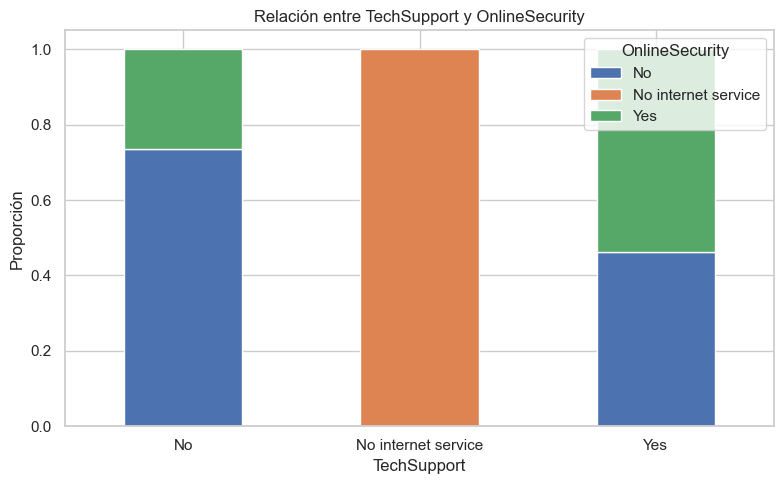

In [21]:
tabla_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Relación entre TechSupport y OnlineSecurity")
plt.xlabel("TechSupport")
plt.ylabel("Proporción")
plt.legend(title="OnlineSecurity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Hay una asociación estructural fuerte entre `TechSupport` y `OnlineSecurity`. Este valor alto de V de Cramér no se debe necesariamente a que tener soporte técnico determine la seguridad en línea, sino a que ambas variables comparten una categoría que depende de la condición: tener o no servicio de Internet.

# 7. Preparación de datos para clustering

Los algoritmos basados en distancia requieren especial cuidado:

- Se elimina `customerID` porque un identificador arbitrario no representa similitud.
- Se excluye `Churn` para mantener el análisis no supervisado.
- Las variables numéricas se estandarizan con `StandardScaler`.
- Las variables categóricas se convierten a numéricas con One-Hot Encoding.

In [22]:
X = df.drop(columns=[ID_COL, TARGET]).copy()
y_ref = df[TARGET].map({"No": 0, "Yes": 1}).to_numpy()

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numéricas:", num_features)
print("Categóricas:", cat_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

X_pre = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

print("Matriz transformada:", X_pre.shape)
print("Es dispersa:", sparse.issparse(X_pre))
print("Número de características después de One-Hot:", len(feature_names))

Numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Matriz transformada: (7043, 46)
Es dispersa: True
Número de características después de One-Hot: 46


### 7.1 Inspección de las nuevas variables

In [23]:
print("Primeras 30 características transformadas:")
print(feature_names[:30])

Primeras 30 características transformadas:
['num__tenure' 'num__MonthlyCharges' 'num__TotalCharges'
 'cat__gender_Female' 'cat__gender_Male' 'cat__SeniorCitizen_No'
 'cat__SeniorCitizen_Yes' 'cat__Partner_No' 'cat__Partner_Yes'
 'cat__Dependents_No' 'cat__Dependents_Yes' 'cat__PhoneService_No'
 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No' 'cat__TechSupport_No internet service']


## 8. Muestra de trabajo para métodos costosos

El clustering jerárquico y t-SNE son más costosos que K-Means. Para mantener un tiempo razonable en este ejemplo se trabaja con una muestra reproducible. Se puede aumentar `N_CLUSTER_SAMPLE` si se dispone de más memoria y tiempo.

In [24]:
N_CLUSTER_SAMPLE = min(4000, X_pre.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
idx = np.sort(rng.choice(X_pre.shape[0], size=N_CLUSTER_SAMPLE, replace=False))

X_work_sparse = X_pre[idx]
y_work = y_ref[idx]
df_work = df.iloc[idx].reset_index(drop=True)

X_work_dense = X_work_sparse.toarray() if sparse.issparse(X_work_sparse) else np.asarray(X_work_sparse)

print("Muestra usada para clustering:", X_work_dense.shape)

Muestra usada para clustering: (4000, 46)


## 9. t-SNE como herramienta de inspección

`t-SNE` se utiliza para visualizar los datos. Se conserva vecindades locales y puede revelar estructuras interesantes, pero también puede crear separaciones visuales que dependen de sus hiperparámetros.

Primero observamos los puntos sin etiquetas. Luego, únicamente con fines de interpretación, se presentan con colores de acuerdo con `Churn`.

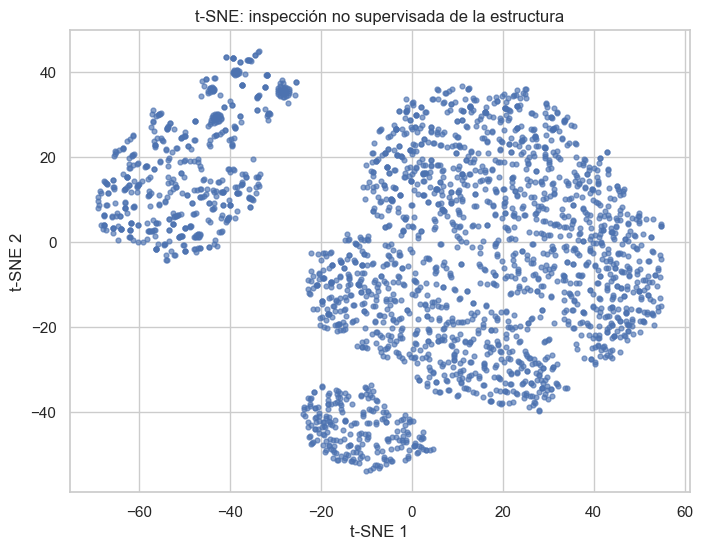

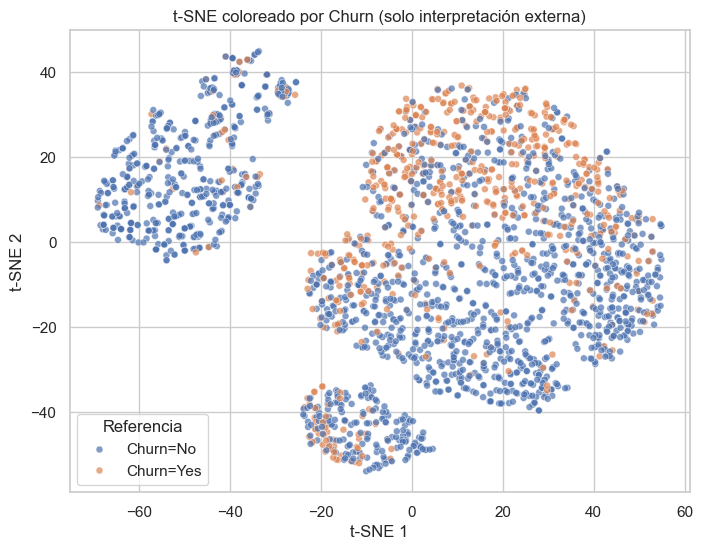

In [25]:
N_TSNE = min(2500, len(X_work_dense))
idx_tsne = rng.choice(len(X_work_dense), size=N_TSNE, replace=False)

X_tsne_input = X_work_dense[idx_tsne]
y_tsne_ref = y_work[idx_tsne]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=RANDOM_STATE
)
X_tsne = tsne.fit_transform(X_tsne_input)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=12, alpha=0.65)
plt.title("t-SNE: inspección no supervisada de la estructura")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=np.where(y_tsne_ref == 1, "Churn=Yes", "Churn=No"),
    s=25, alpha=0.7
)
plt.title("t-SNE coloreado por Churn (solo interpretación externa)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Referencia")
plt.show()

## 10. Funciones de evaluación de clustering

Utilizaremos cuatro criterios principales:

- Silhouette: mayor es mejor.
- Davies-Bouldin (DB): menor es mejor.
- Calinski-Harabasz (CH): mayor es mejor.
- Cobertura: porcentaje de observaciones asignadas a clusters; es especialmente importante para DBSCAN, que puede etiquetar puntos como ruido (`-1`).

Además calcularemos ARI y NMI contra `Churn` como una referencia externa secundaria.

In [26]:
def clustering_metrics(X_eval, labels, y_external=None):
    labels = np.asarray(labels)
    noise_mask = labels == -1
    valid = ~noise_mask
    unique_valid = np.unique(labels[valid])

    result = {
        "n_clusters": len(unique_valid),
        "noise_pct": 100 * noise_mask.mean(),
        "coverage_pct": 100 * valid.mean(),
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
        "ARI_vs_Churn": np.nan,
        "NMI_vs_Churn": np.nan,
    }

    if valid.sum() >= 3 and len(unique_valid) >= 2:
        Xv = X_eval[valid]
        lv = labels[valid]
        result["silhouette"] = silhouette_score(Xv, lv)
        result["davies_bouldin"] = davies_bouldin_score(Xv, lv)
        result["calinski_harabasz"] = calinski_harabasz_score(Xv, lv)

        if y_external is not None:
            yv = np.asarray(y_external)[valid]
            result["ARI_vs_Churn"] = adjusted_rand_score(yv, lv)
            result["NMI_vs_Churn"] = normalized_mutual_info_score(yv, lv)

    return result

In [27]:
#Función que construye un ranking agregado a partir de tres métricas internas.
#    - Silhouette: mayor es mejor
#    - Davies-Bouldin: menor es mejor
#    - Calinski-Harabasz: mayor es mejor

def crear_ranking_clustering(
    resultados,
    col_silhouette="Silhouette",
    col_db="Davies-Bouldin",
    col_ch="Calinski-Harabasz"
):
    
    df_rank = resultados.copy()
    df_rank["Rank_Silhouette"] = df_rank[col_silhouette].rank(ascending=False, method="min")
    df_rank["Rank_DaviesBouldin"] = df_rank[col_db].rank(ascending=True, method="min")
    df_rank["Rank_CalinskiHarabasz"] = df_rank[col_ch].rank(ascending=False, method="min")

    df_rank["Rank_Total"] = (df_rank["Rank_Silhouette"] + df_rank["Rank_DaviesBouldin"] + df_rank["Rank_CalinskiHarabasz"])
    df_rank["Ranking"] = df_rank["Rank_Total"].rank(ascending=True, method="min").astype(int)

    return df_rank.sort_values(["Ranking", "Rank_Total"]).reset_index(drop=True)

## 11. Selección exploratoria del número de clusters para K-Means

K-Means necesita especificar `k`. Probamos valores de 2 a 8 y observamos inercia y silhouette. Para automatizar el notebook, se seleccionará el `k` con mayor silhouette; en clase conviene discutir que la elección no debe depender de una sola métrica.

In [28]:
k_values = range(2, 9)

resultados_kmeans = []

for k in k_values:

    km = KMeans(n_clusters=k, n_init=20,  random_state=RANDOM_STATE)
    labels = km.fit_predict(X_work_sparse)
    silhouette = silhouette_score(X_work_sparse, labels)

    davies = davies_bouldin_score(
        X_work_sparse.toarray()
        if hasattr(X_work_sparse, "toarray")
        else X_work_sparse,
        labels
    )

    calinski = calinski_harabasz_score(
        X_work_sparse.toarray()
        if hasattr(X_work_sparse, "toarray")
        else X_work_sparse,
        labels
    )

    resultados_kmeans.append({
        "k": k,
        "Inercia": km.inertia_,
        "Silhouette": silhouette,
        "Davies-Bouldin": davies,
        "Calinski-Harabasz": calinski
    })

In [29]:
df_kmeans = pd.DataFrame(resultados_kmeans)
print(df_kmeans.round(4))

   k     Inercia  Silhouette  Davies-Bouldin  Calinski-Harabasz
0  2  36096.5973      0.2516          1.3397          1203.2094
1  3  28757.5170      0.2494          1.6151          1264.9772
2  4  26647.6383      0.2043          1.9511          1015.3255
3  5  25297.1278      0.1873          2.1262           855.2656
4  6  24233.0035      0.1511          2.1264           749.1560
5  7  23414.7870      0.1332          2.1513           669.2061
6  8  22704.6472      0.1319          2.2130           609.2349


In [30]:
ranking_kmeans = crear_ranking_clustering(df_kmeans)
display(ranking_kmeans.round(4))

,k,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz,Rank_Silhouette,Rank_DaviesBouldin,Rank_CalinskiHarabasz,Rank_Total,Ranking
0,2,36096.5973,0.2516,1.3397,1203.2094,1.0,1.0,2.0,4.0,1
1,3,28757.5170,0.2494,1.6151,1264.9772,2.0,2.0,1.0,5.0,2
2,4,26647.6383,0.2043,1.9511,1015.3255,3.0,3.0,3.0,9.0,3
3,5,25297.1278,0.1873,2.1262,855.2656,4.0,4.0,4.0,12.0,4
4,6,24233.0035,0.1511,2.1264,749.1560,5.0,5.0,5.0,15.0,5
5,7,23414.7870,0.1332,2.1513,669.2061,6.0,6.0,6.0,18.0,6
6,8,22704.6472,0.1319,2.2130,609.2349,7.0,7.0,7.0,21.0,7


In [32]:
results = []
labels_store = {}
BEST_K = int(ranking_kmeans.iloc[0]["k"])

km = KMeans(n_clusters=BEST_K, n_init=20, random_state=RANDOM_STATE)
labels_km = km.fit_predict(X_work_sparse)
labels_store[("Original", "K-Means")] = labels_km

m = clustering_metrics(X_work_dense, labels_km, y_work)
m.update({"representation": "Original", "method": "K-Means"})
results.append(m)

pd.DataFrame([m])

,n_clusters,noise_pct,coverage_pct,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_Churn,NMI_vs_Churn,representation,method
0,2,0.0,100.0,0.251601,1.339685,1203.209377,-0.063099,0.054066,Original,K-Means


### 12.2 Clustering jerárquico aglomerativo

Ahora aplicamos Clustering jerárquico aglomerativo sobre los datos completos y evaluamos diferentes hiperparámetros.

In [34]:
linkages = ["single", "complete", "average", "ward"]
k_values = range(2, 5)

resultados_hier = []

for linkage in linkages:
    for k in k_values:
        modelo = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = modelo.fit_predict(X_work_dense)
        silhouette = silhouette_score(X_work_dense, labels)
        davies = davies_bouldin_score(X_work_dense, labels)
        calinski = calinski_harabasz_score(X_work_dense, labels)

        resultados_hier.append({
            "linkage": linkage,
            "k": k,
            "Silhouette": silhouette,
            "Davies-Bouldin": davies,
            "Calinski-Harabasz": calinski
        })

In [35]:
df_hier = pd.DataFrame(resultados_hier)
display(df_hier.round(4))

,linkage,k,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,single,2,0.2516,1.3397,1203.2094
1,single,3,0.1037,1.2267,602.1783
2,single,4,0.0404,1.1712,401.8307
3,complete,2,0.1708,1.8580,822.4760
4,complete,3,0.1335,2.2429,737.2754
5,complete,4,0.1341,2.1990,617.3254
6,average,2,0.2516,1.3397,1203.2094
7,average,3,0.2305,1.6882,1138.6328
8,average,4,0.2170,1.8557,905.3725
9,ward,2,0.2516,1.3397,1203.2094


In [36]:
ranking_hier = crear_ranking_clustering(df_hier)
display(ranking_hier.round(4))

,linkage,k,Silhouette,Davies-Bouldin,Calinski-Harabasz,Rank_Silhouette,Rank_DaviesBouldin,Rank_CalinskiHarabasz,Rank_Total,Ranking
0,single,2,0.2516,1.3397,1203.2094,1.0,3.0,1.0,5.0,1
1,average,2,0.2516,1.3397,1203.2094,1.0,3.0,1.0,5.0,1
2,ward,2,0.2516,1.3397,1203.2094,1.0,3.0,1.0,5.0,1
3,ward,3,0.2354,1.6938,1194.8336,4.0,7.0,4.0,15.0,4
4,average,3,0.2305,1.6882,1138.6328,5.0,6.0,5.0,16.0,5
5,average,4,0.2170,1.8557,905.3725,6.0,8.0,7.0,21.0,6
6,ward,4,0.1874,1.9812,940.1903,7.0,10.0,6.0,23.0,7
7,single,3,0.1037,1.2267,602.1783,11.0,2.0,11.0,24.0,8
8,single,4,0.0404,1.1712,401.8307,12.0,1.0,12.0,25.0,9
9,complete,2,0.1708,1.8580,822.4760,8.0,9.0,8.0,25.0,9


In [40]:
best_hier = ranking_hier.iloc[0]

BEST_HIER_K = int(best_hier["k"])
BEST_LINKAGE = best_hier["linkage"]

print("Mejor configuración jerárquica:")
print("k =", BEST_HIER_K)
print("linkage =", BEST_LINKAGE)

Mejor configuración jerárquica:
k = 2
linkage = single


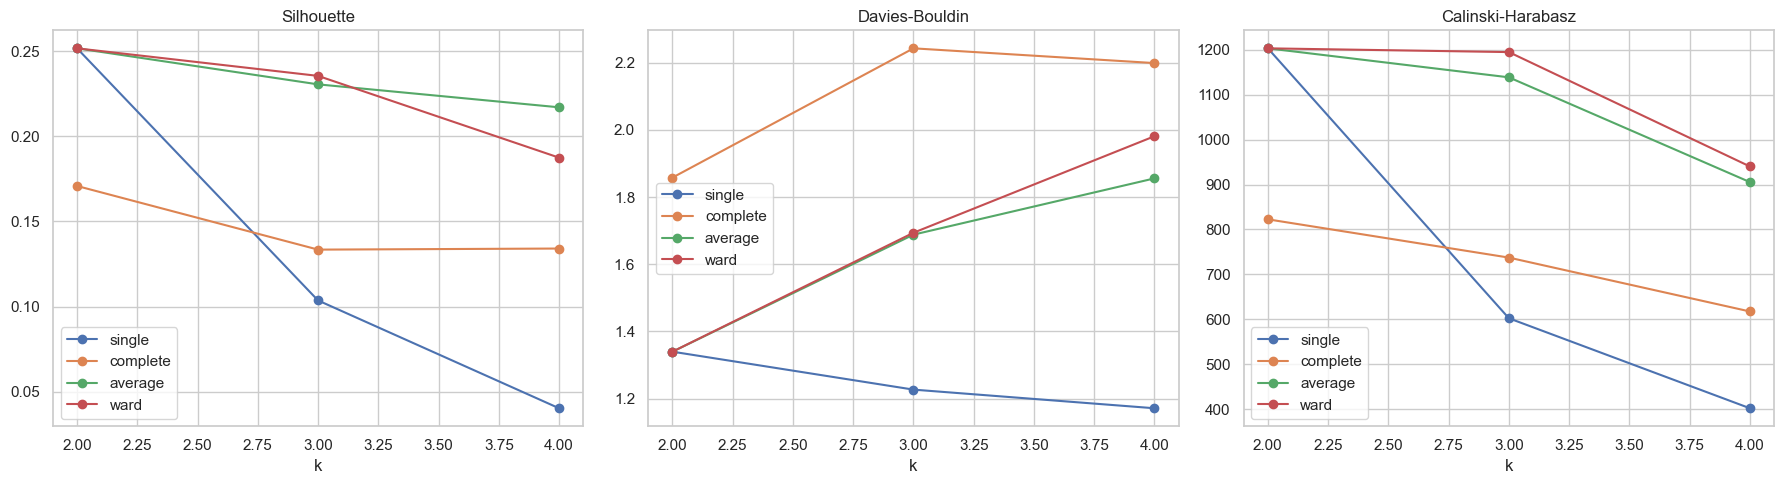

In [43]:
fig, axes = plt.subplots(1,3,figsize=(18, 5))

for linkage in linkages:

    temp = df_hier[df_hier["linkage"] == linkage]
    axes[0].plot(temp["k"], temp["Silhouette"],  marker="o", label=linkage)
    axes[1].plot(temp["k"], temp["Davies-Bouldin"],  marker="o", label=linkage)
    axes[2].plot(temp["k"], temp["Calinski-Harabasz"], marker="o", label=linkage)

axes[0].set_title("Silhouette")
axes[1].set_title("Davies-Bouldin")
axes[2].set_title("Calinski-Harabasz")

for ax in axes:
    ax.set_xlabel("k")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [45]:
hier_best = AgglomerativeClustering( n_clusters=BEST_HIER_K, linkage=BEST_LINKAGE)
labels_hier = hier_best.fit_predict(X_work_dense)
labels_store[("Original", "Jerárquico")] = labels_hier

In [46]:
m_hier = clustering_metrics(X_work_dense,  labels_hier, y_work)
m_hier.update({"representation": "Original",  "method": "Jerárquico", "linkage": BEST_LINKAGE, "k": BEST_HIER_K})
results.append(m_hier)
pd.DataFrame([m_hier])

,n_clusters,noise_pct,coverage_pct,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_Churn,NMI_vs_Churn,representation,method,linkage,k
0,2,0.0,100.0,0.251601,1.339685,1203.209377,-0.063099,0.054066,Original,Jerárquico,single,2


### 12.3 DBSCAN

DBSCAN no necesita indicar el número de clusters, pero sí `eps` y `min_samples`. En alta dimensión puede resultar difícil encontrar densidades bien separadas; precisamente por eso es interesante compararlo antes y después de reducción dimensional.

El histograma muestra cómo se distribuyen las distancias al 5.º vecino más cercano para todas las observaciones del dataset.

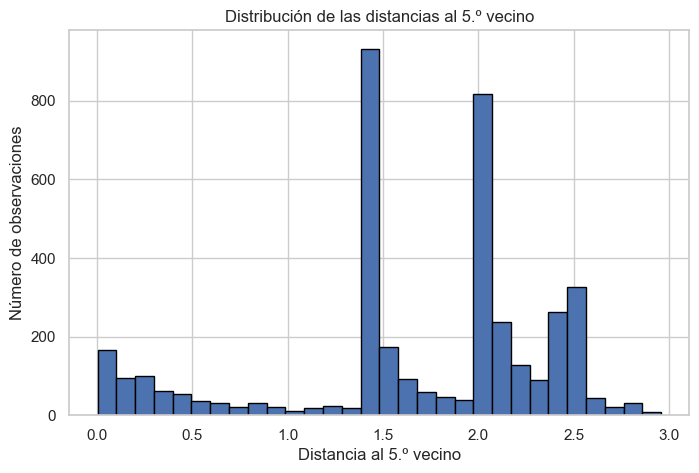

In [51]:
k=5
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_work_dense)
k_distances = distances[:, -1]

distances, indices = nn.kneighbors(X_work_dense)
plt.figure(figsize=(8, 5))
plt.hist(k_distances, bins=30, edgecolor="black")
plt.xlabel("Distancia al 5.º vecino")
plt.ylabel("Número de observaciones")
plt.title("Distribución de las distancias al 5.º vecino")

plt.show()

In [55]:
def tune_dbscan(X_rep, y_external=None, min_samples_options=(5, 8, 12)):
    
    d5 = distances[:, -1]
    eps_candidates = np.unique(np.quantile(d5, [0.80, 0.90, 0.95]))

    # ---------------------------------------------------------
    # 2. Evaluar todas las combinaciones
    # ---------------------------------------------------------
    rows = []
    label_candidates = {}

    for eps in eps_candidates:
        for ms in min_samples_options:
            model = DBSCAN(eps=float(eps),  min_samples=int(ms), metric="euclidean")
            
            labels = model.fit_predict(X_rep)
            met = clustering_metrics(X_rep, labels, y_external)

            row = {
                "eps": float(eps),
                "min_samples": int(ms),
                **met
            }

            rows.append(row)

            label_candidates[(float(eps), int(ms))] = labels

    grid = pd.DataFrame(rows)

    # ---------------------------------------------------------
    # 3. Filtrar soluciones válidas
    # ---------------------------------------------------------
    # Se exige:
    # - al menos 2 clusters
    # - cobertura >= 50 %
    # - métricas calculables

    valid = grid[
        (grid["n_clusters"] >= 2)
        & (grid["coverage_pct"] >= 50)
        & grid["silhouette"].notna()
        & grid["davies_bouldin"].notna()
        & grid["calinski_harabasz"].notna()
    ].copy()

    # Si ninguna alcanza 50 % de cobertura,
    # relajamos solamente este criterio.
    if len(valid) == 0:

        valid = grid[
            (grid["n_clusters"] >= 2)
            & grid["silhouette"].notna()
            & grid["davies_bouldin"].notna()
            & grid["calinski_harabasz"].notna()
        ].copy()

    # ---------------------------------------------------------
    # 4. Si no existe ninguna solución válida
    # ---------------------------------------------------------
    if len(valid) == 0:
        return (None, None, grid.sort_values("coverage_pct", ascending=False))

    # ---------------------------------------------------------
    # 5. Ranking agregado
    # ---------------------------------------------------------
    ranking_dbscan = crear_ranking_clustering(
        valid,
        col_silhouette="silhouette",
        col_db="davies_bouldin",
        col_ch="calinski_harabasz"
    )

    # ---------------------------------------------------------
    # 6. Seleccionar mejor configuración
    # ---------------------------------------------------------
    best = ranking_dbscan.iloc[0]
    key = (float(best["eps"]), int(best["min_samples"]))
    best_labels = label_candidates[key]

    return (best, best_labels, ranking_dbscan)

In [56]:
best_db, labels_db, db_ranking = tune_dbscan(X_work_dense, y_work)
display(db_ranking.round(4))

,eps,min_samples,n_clusters,noise_pct,coverage_pct,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_Churn,NMI_vs_Churn,Rank_Silhouette,Rank_DaviesBouldin,Rank_CalinskiHarabasz,Rank_Total,Ranking
0,2.2500,8,2,13.950,86.050,0.2712,1.3146,1217.9257,-0.0427,0.0754,1.0,2.0,1.0,4.0,1
1,2.5030,12,2,3.875,96.125,0.2572,1.3314,1211.6143,-0.0590,0.0593,3.0,3.0,2.0,8.0,2
2,2.4683,8,2,4.350,95.650,0.2574,1.3317,1209.6957,-0.0587,0.0596,2.0,4.0,3.0,9.0,3
3,2.5030,8,2,2.050,97.950,0.2546,1.3351,1208.2912,-0.0613,0.0564,4.0,5.0,4.0,13.0,4
4,2.5030,5,2,0.925,99.075,0.2529,1.3378,1205.1946,-0.0622,0.0553,5.0,6.0,5.0,16.0,5
5,2.2500,5,6,8.200,91.800,0.0808,1.2774,245.4123,-0.0541,0.0655,9.0,1.0,9.0,19.0,6
6,2.4683,12,3,8.250,91.750,0.1606,1.4908,618.0520,-0.0539,0.0657,6.0,8.0,6.0,20.0,7
7,2.4683,5,3,2.200,97.800,0.1301,1.4200,605.9428,-0.0613,0.0573,7.0,7.0,7.0,21.0,8
8,2.2500,12,4,18.950,81.050,0.0997,1.5152,420.3054,-0.0297,0.0865,8.0,9.0,8.0,25.0,9


In [57]:
if best_db is not None:

    print("Mejor configuración DBSCAN según ranking agregado:")
    display(best_db.to_frame().T.round(4))
    labels_store[("Original", "DBSCAN")] = labels_db

    m = clustering_metrics(X_work_dense, labels_db, y_work)

    m.update({
        "representation": "Original",
        "method": "DBSCAN",
        "eps": float(best_db["eps"]),
        "min_samples": int(best_db["min_samples"])
    })

    results.append(m)

else:
    print(
        "DBSCAN no encontró una solución "
        "con al menos dos clusters "
        "en la rejilla explorada."
    )

Mejor configuración DBSCAN según ranking agregado:


,eps,min_samples,n_clusters,noise_pct,coverage_pct,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_Churn,NMI_vs_Churn,Rank_Silhouette,Rank_DaviesBouldin,Rank_CalinskiHarabasz,Rank_Total,Ranking
0,2.25,8.0,2.0,13.95,86.05,0.2712,1.3146,1217.9257,-0.0427,0.0754,1.0,2.0,1.0,4.0,1.0


### 12.4 Resultados de la línea base

In [59]:
baseline_results = pd.DataFrame(results)
baseline_results = baseline_results.drop_duplicates(subset=["representation", "method"], keep="last")

display(baseline_results[
        ["representation", "method", "n_clusters", "coverage_pct", "noise_pct",
         "silhouette", "davies_bouldin", "calinski_harabasz", "ARI_vs_Churn", "NMI_vs_Churn"]
    ].round(4))

,representation,method,n_clusters,coverage_pct,noise_pct,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_Churn,NMI_vs_Churn
0,Original,K-Means,2,100.00,0.00,0.2516,1.3397,1203.2094,-0.0631,0.0541
2,Original,Jerárquico,2,100.00,0.00,0.2516,1.3397,1203.2094,-0.0631,0.0541
4,Original,DBSCAN,2,86.05,13.95,0.2712,1.3146,1217.9257,-0.0427,0.0754


## 13. Reducción de dimensionalidad

Para comparar de forma relativamente justa, usaremos un espacio latente de la misma dimensión (`N_COMPONENTS`) en PCA, Truncated SVD y autoencoder.

In [66]:
#Selección de N_COMPONENTS

pca_full = PCA()
pca_full.fit(X_work_dense)

var_acum = np.cumsum(pca_full.explained_variance_ratio_)

n_components_90 = np.argmax(var_acum >= 0.90) + 1
n_components_99 = np.argmax(var_acum >= 0.99) + 1

print("Componentes para 90%:", n_components_90)
print("Componentes para 99%:", n_components_99)

Componentes para 90%: 15
Componentes para 99%: 21


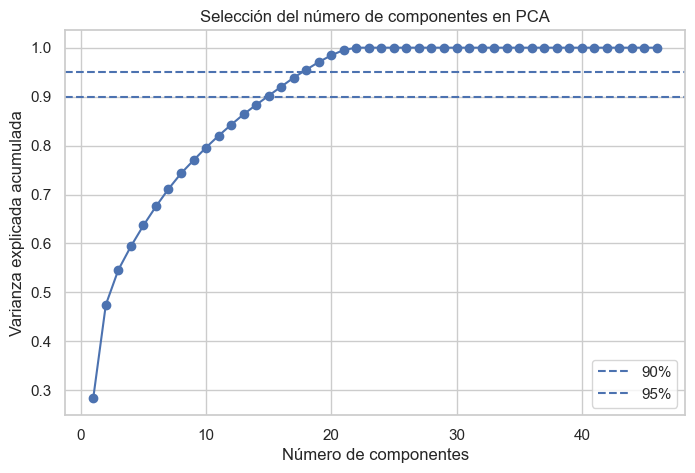

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(var_acum) + 1), var_acum, marker="o")

plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")

plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Selección del número de componentes en PCA")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
N_COMPONENTS = n_components_99

### 13.1 PCA

In [76]:
pca = PCA(
    n_components=N_COMPONENTS,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(X_work_dense)

print("Dimensión original:", X_work_dense.shape)
print("Dimensión después de PCA:", X_pca.shape)

Dimensión original: (4000, 46)
Dimensión después de PCA: (4000, 21)


### 13.2 Truncated SVD

In [77]:
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_svd = svd.fit_transform(X_work_sparse)

print("Proporción de varianza explicada acumulada (SVD):",
      round(svd.explained_variance_ratio_.sum(), 4))

Proporción de varianza explicada acumulada (SVD): 0.9845


### 13.3 Autoencoder

El autoencoder comprime los datos hacia un cuello de botella de `N_COMPONENTS` dimensiones y luego intenta reconstruir la entrada original. La representación latente aprendida por el encoder se utilizará para clustering.

In [78]:
input_dim = X_work_dense.shape[1]
latent_dim = N_COMPONENTS

encoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(latent_dim, activation="linear", name="latent")
], name="encoder")

decoder = keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(input_dim, activation="linear")
], name="decoder")

entrada = keras.Input(shape=(input_dim,))
z = encoder(entrada)
salida = decoder(z)
autoencoder = keras.Model(entrada, salida, name="autoencoder")

autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 46)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder (Sequential)                 │ (None, 21)                  │           5,781 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Sequential)                 │ (None, 46)                  │           5,806 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,587 (45.26 KB)

 Trainable params: 11,587 (45.26 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_work_dense,
    X_work_dense,
    validation_split=0.2,
    epochs=100,
    batch_size=128,
    shuffle=True,
    callbacks=[early_stop],
    verbose=0
)

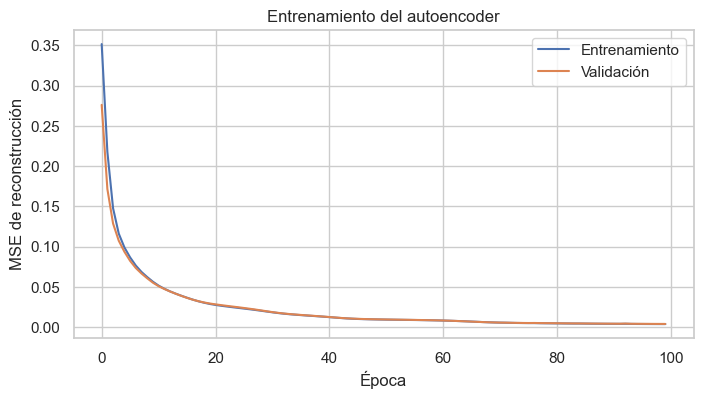

In [80]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("MSE de reconstrucción")
plt.title("Entrenamiento del autoencoder")
plt.legend()
plt.show()

In [83]:
X_ae = encoder.predict(X_work_dense, verbose=0)
print("Dimensiones del espacio latente:", X_ae.shape)

Dimensiones del espacio latente: (4000, 21)


## 14. Estandarización de los espacios reducidos

Aunque PCA y SVD generan nuevas escalas, y el autoencoder puede producir escalas arbitrarias, estandarizamos cada representación reducida antes del clustering. Así evitamos que una dimensión domine las distancias solo por su escala.

In [84]:
def standardize_representation(Z):
    return StandardScaler().fit_transform(Z)

representations = {
    "PCA": standardize_representation(X_pca),
    "Truncated SVD": standardize_representation(X_svd),
    "Autoencoder": standardize_representation(X_ae),
}

for name, Z in representations.items():
    print(name, Z.shape)

PCA (4000, 21)
Truncated SVD (4000, 21)
Autoencoder (4000, 21)


## 15. Clustering después de reducción dimensional

Aplicamos los mismos tres métodos sobre cada representación. Para K-Means y jerárquico mantenemos `BEST_K`, con el fin de comparar el efecto de la representación sin cambiar simultáneamente el número de clusters. DBSCAN sí requiere volver a ajustar `eps`, porque las distancias cambian al cambiar de espacio.

In [85]:
for rep_name, Z in representations.items():
    print("\n===", rep_name, "===")

    # K-Means
    km = KMeans(n_clusters=BEST_K, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(Z)
    labels_store[(rep_name, "K-Means")] = labels
    m = clustering_metrics(Z, labels, y_work)
    m.update({"representation": rep_name, "method": "K-Means"})
    results.append(m)

    # Jerárquico
    hc = AgglomerativeClustering(n_clusters=BEST_K, linkage="ward")
    labels = hc.fit_predict(Z)
    labels_store[(rep_name, "Jerárquico")] = labels
    m = clustering_metrics(Z, labels, y_work)
    m.update({"representation": rep_name, "method": "Jerárquico"})
    results.append(m)

    # DBSCAN con ajuste en el nuevo espacio
    best_db, labels, grid = tune_dbscan(Z, y_work)
    if best_db is not None:
        labels_store[(rep_name, "DBSCAN")] = labels
        m = clustering_metrics(Z, labels, y_work)
        m.update({"representation": rep_name, "method": "DBSCAN"})
        results.append(m)
        print(
            f"DBSCAN: eps={best_db['eps']:.3f}, min_samples={int(best_db['min_samples'])}, "
            f"clusters={int(best_db['n_clusters'])}, ruido={best_db['noise_pct']:.1f}%"
        )
    else:
        print("DBSCAN: no se encontró configuración válida.")


=== PCA ===
DBSCAN: eps=2.250, min_samples=12, clusters=27, ruido=83.0%

=== Truncated SVD ===
DBSCAN: eps=2.250, min_samples=12, clusters=24, ruido=83.1%

=== Autoencoder ===
DBSCAN: eps=2.250, min_samples=8, clusters=4, ruido=37.9%


## 16. Comparación global de resultados

No existe una única métrica universalmente mejor. La interpretación conjunta es esencial:

- Silhouette alta favorece clusters compactos y separados.
- Davies-Bouldin bajo favorece separación relativa respecto a dispersión.
- Calinski-Harabasz alto recompensa separación entre clusters frente a cohesión interna.
- Para DBSCAN debemos considerar también la cobertura y el porcentaje de ruido.
- ARI/NMI contra `Churn` no deben dominar la decisión, porque `Churn` no necesariamente representa los segmentos naturales de clientes.

In [88]:
results_df = pd.DataFrame(results)
cols_show = [
    "representation", "method", "n_clusters", "coverage_pct", "noise_pct",
    "silhouette", "davies_bouldin", "calinski_harabasz",
    "ARI_vs_Churn", "NMI_vs_Churn"
]
results_df = results_df[cols_show]
display(results_df.round(4))

,representation,method,n_clusters,coverage_pct,noise_pct,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_Churn,NMI_vs_Churn
0,Original,K-Means,2,100.000,0.000,0.2516,1.3397,1203.2094,-0.0631,0.0541
1,Original,Jerárquico,2,100.000,0.000,0.2516,1.3397,1203.2094,-0.0631,0.0541
2,Original,Jerárquico,2,100.000,0.000,0.2516,1.3397,1203.2094,-0.0631,0.0541
3,Original,DBSCAN,2,86.050,13.950,0.2712,1.3146,1217.9257,-0.0427,0.0754
4,Original,DBSCAN,2,86.050,13.950,0.2712,1.3146,1217.9257,-0.0427,0.0754
5,PCA,K-Means,2,100.000,0.000,0.0494,4.3321,199.8984,0.0007,0.0336
6,PCA,Jerárquico,2,100.000,0.000,0.1192,2.5903,198.5286,0.0002,0.0000
7,PCA,DBSCAN,27,17.025,82.975,0.4334,1.0459,105.3247,0.0211,0.1379
8,Truncated SVD,K-Means,2,100.000,0.000,0.0858,2.9951,358.2338,-0.0306,0.0359
9,Truncated SVD,Jerárquico,2,100.000,0.000,0.0858,2.9951,358.2338,-0.0306,0.0359


### 16.1 Comparación gráfica de métricas internas

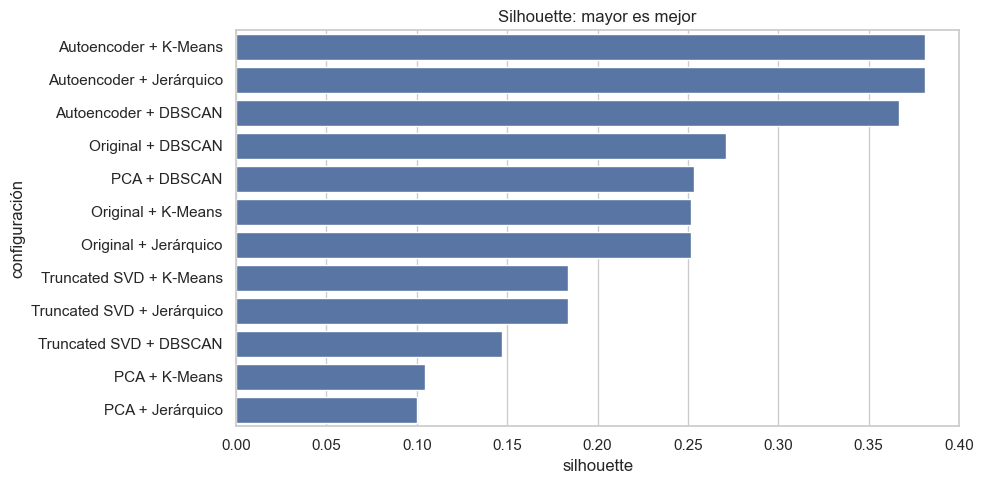

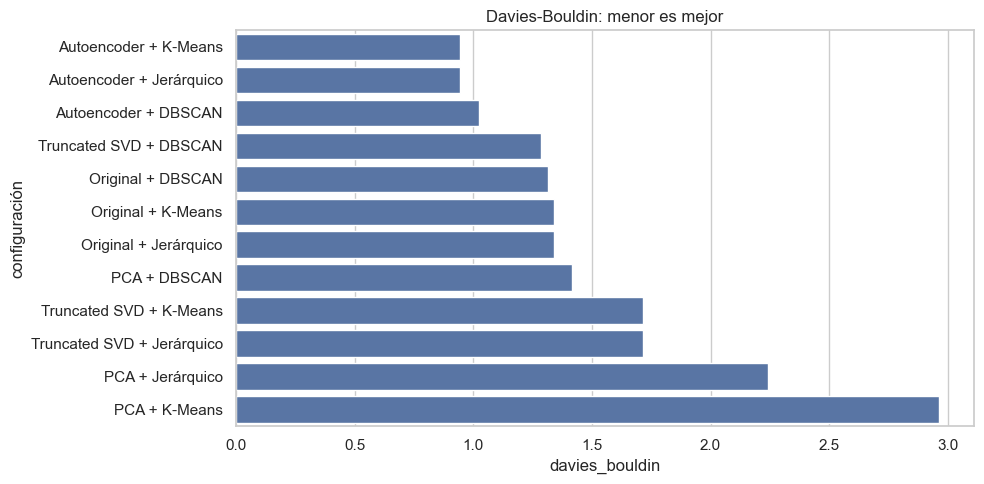

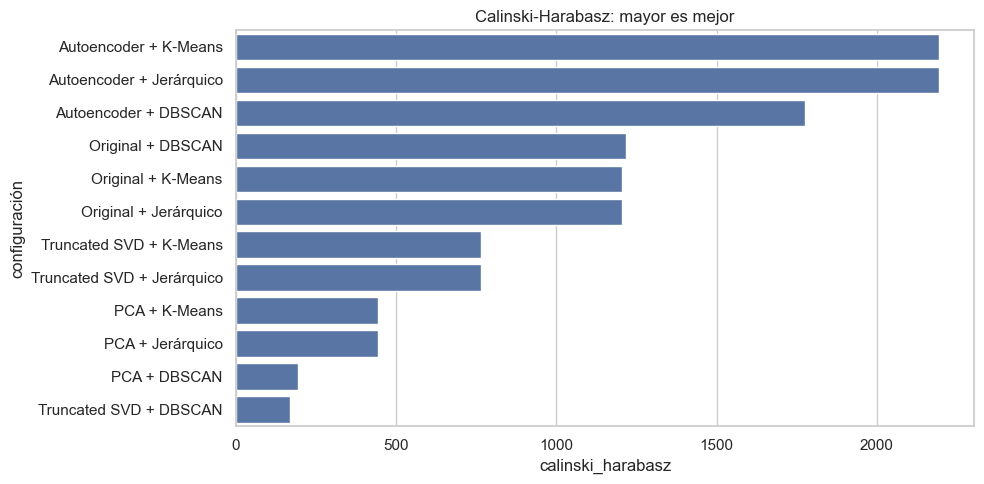

In [34]:
plot_df = results_df.copy()
plot_df["configuración"] = plot_df["representation"] + " + " + plot_df["method"]

for metric, title in [
    ("silhouette", "Silhouette: mayor es mejor"),
    ("davies_bouldin", "Davies-Bouldin: menor es mejor"),
    ("calinski_harabasz", "Calinski-Harabasz: mayor es mejor"),
]:
    temp = plot_df.dropna(subset=[metric]).sort_values(metric, ascending=(metric == "davies_bouldin"))
    plt.figure(figsize=(10, 5))
    sns.barplot(data=temp, y="configuración", x=metric)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 17. Visualización 2D de las soluciones encontradas

Para visualizar cada clustering de forma comparable, proyectamos la representación utilizada por el algoritmo a dos dimensiones con PCA cuando sea necesario. Esta proyección sirve para mostrar los resultados, pero las métricas se calculan en el espacio de trabajo correspondiente, no en esta figura 2D.

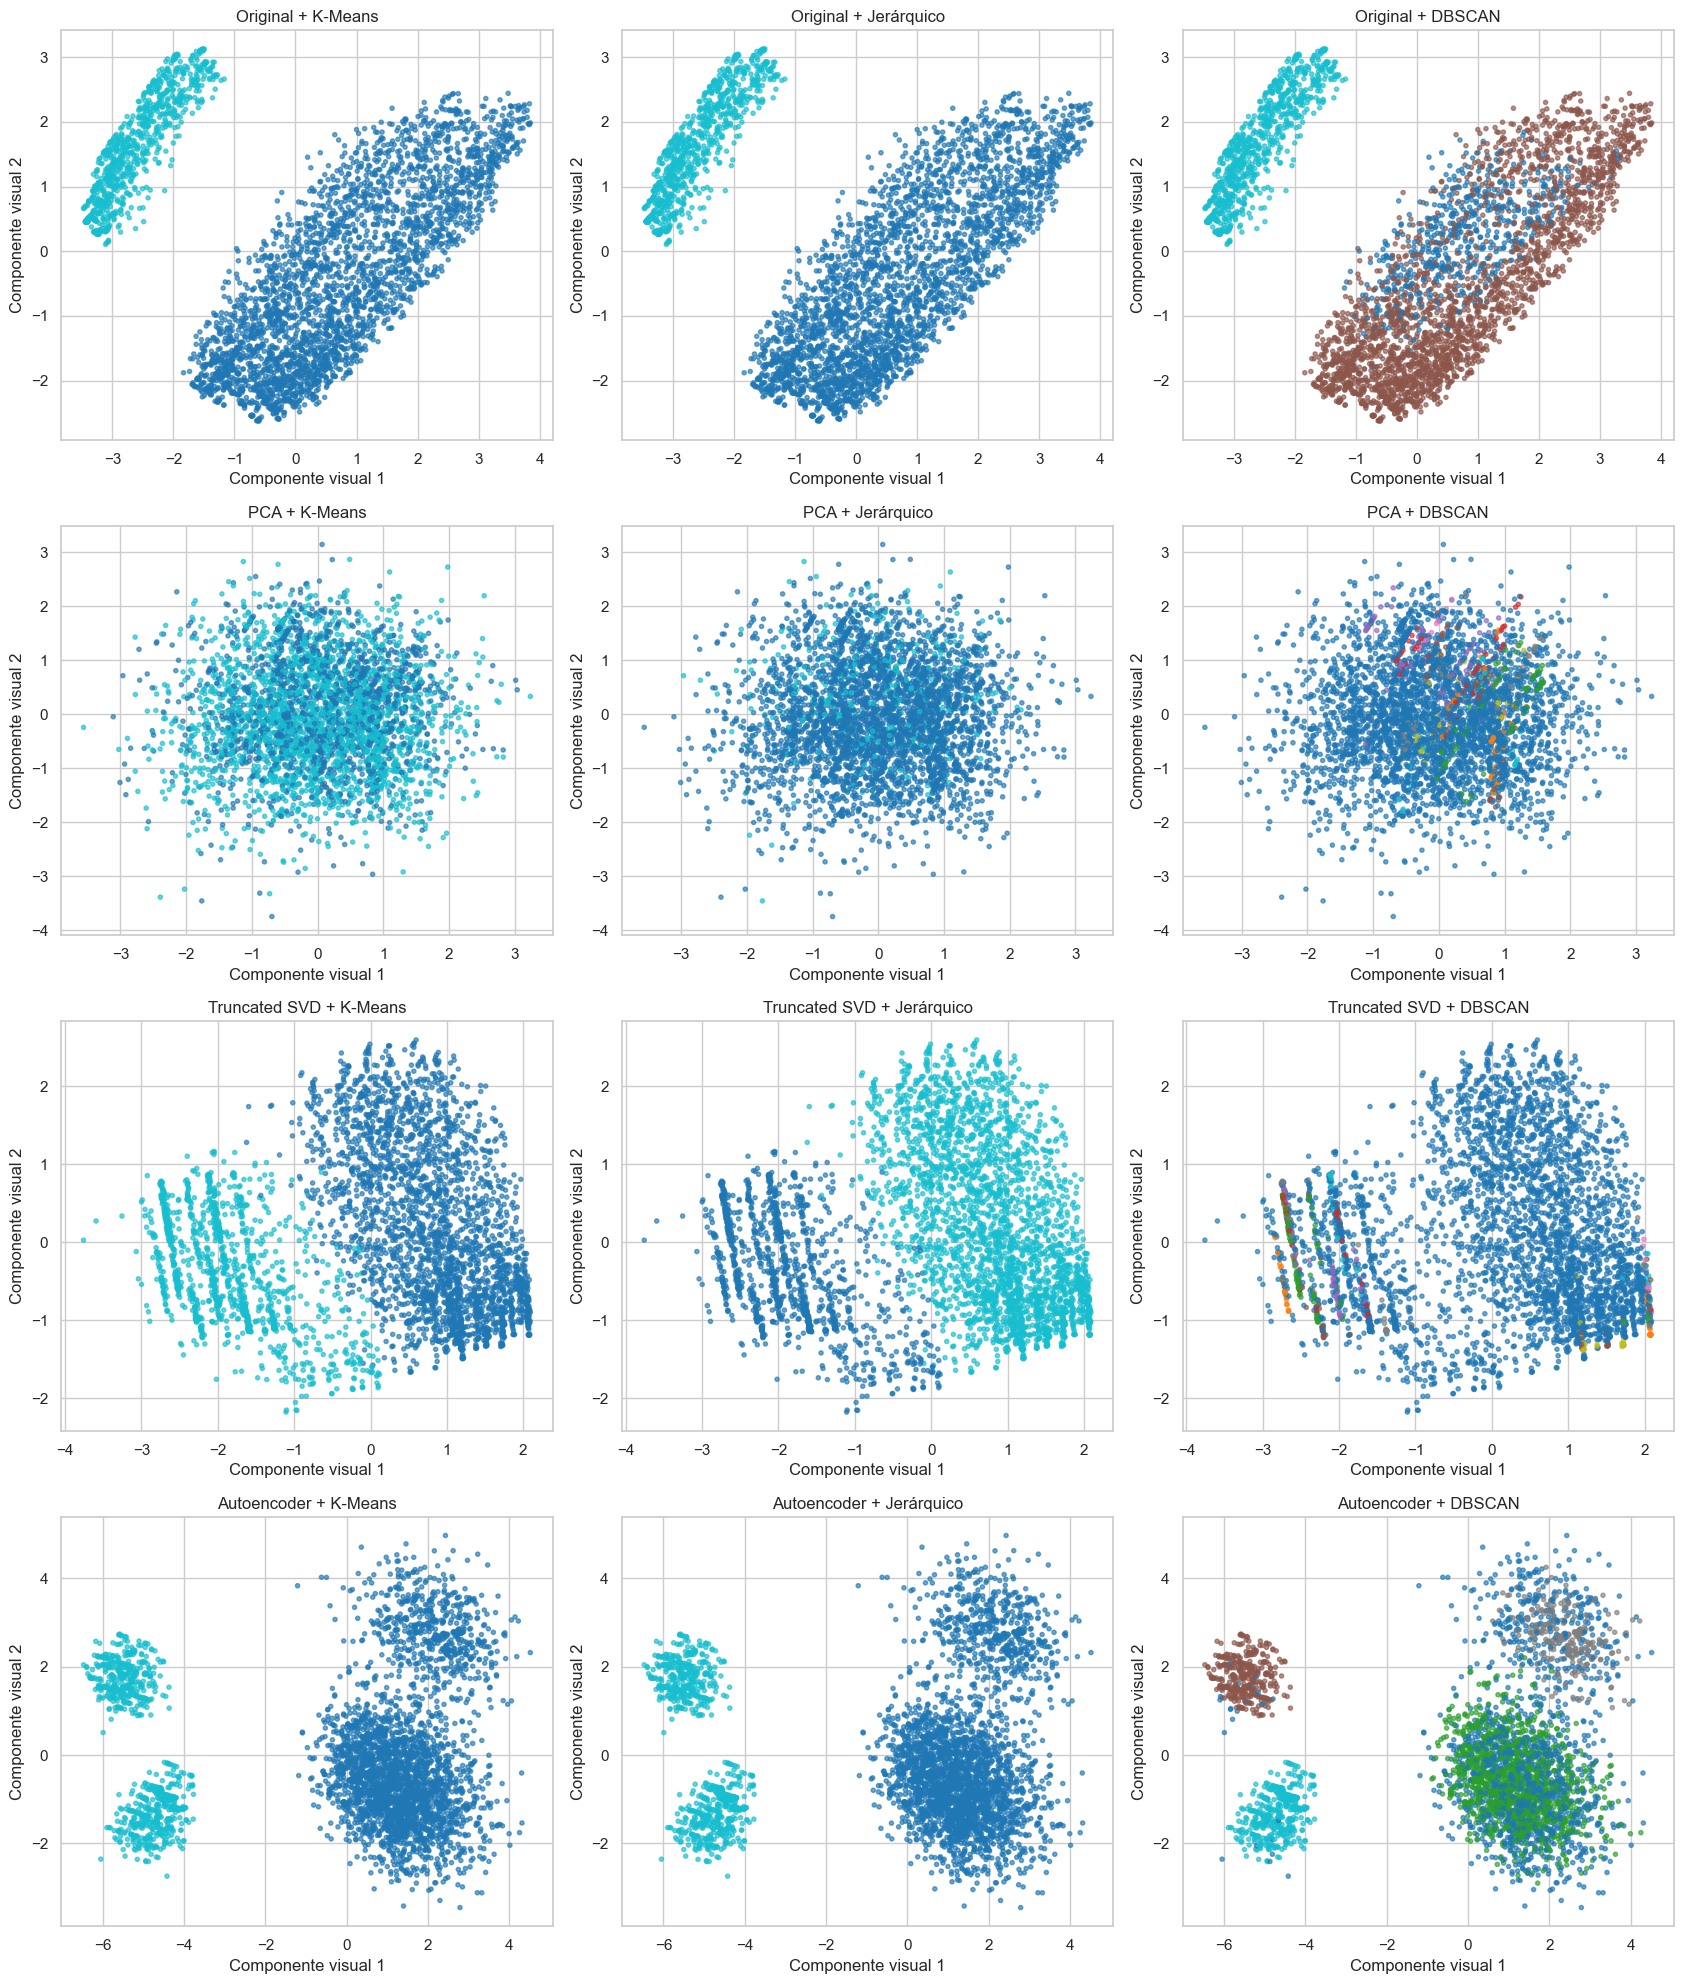

In [91]:
rep_for_plot = {"Original": X_work_dense,  **representations}

def to_2d(Z):
    if Z.shape[1] == 2:
        return Z
    return PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Z)

configs_to_plot = list(labels_store.keys())
ncols = 3
nrows = int(np.ceil(len(configs_to_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, key in zip(axes, configs_to_plot):
    rep_name, method = key
    Z2 = to_2d(rep_for_plot[rep_name])
    labels = labels_store[key]
    ax.scatter(Z2[:, 0], Z2[:, 1], c=labels, s=9, alpha=0.65, cmap="tab10")
    ax.set_title(f"{rep_name} + {method}")
    ax.set_xlabel("Componente visual 1")
    ax.set_ylabel("Componente visual 2")

for ax in axes[len(configs_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 18. Perfilado e interpretación de la mejor solución

Las métricas internas indican qué solución tiene mejor geometría, pero un clustering útil también debe ser interpretable. Seleccionamos automáticamente la configuración con mayor silhouette entre aquellas con cobertura de al menos 70%.

Luego regresamos a las variables originales para describir cada grupo.

In [90]:
valid_for_choice = results_df[
    results_df["silhouette"].notna() & (results_df["coverage_pct"] >= 70)
]

if len(valid_for_choice) == 0:
    valid_for_choice = results_df[results_df["silhouette"].notna()]

best_row = valid_for_choice.sort_values("silhouette", ascending=False).iloc[0]
best_key = (best_row["representation"], best_row["method"])
best_labels = labels_store[best_key]

print("Mejor configuración geométrica:", best_key)
display(best_row.to_frame().T)

profile = df_work.copy()
profile["cluster"] = best_labels

# Excluimos ruido de DBSCAN del perfil de clusters, pero lo reportamos por separado.
profile_clusters = profile[profile["cluster"] != -1].copy()

print("\nTamaño de cada cluster:")
display(profile["cluster"].value_counts().sort_index().to_frame("n"))

print("\nPerfil numérico (medias):")
display(profile_clusters.groupby("cluster")[numeric_cols].mean().round(2))

print("\nProporción de Churn por cluster (solo interpretación):")
display(pd.crosstab(profile_clusters["cluster"], profile_clusters["Churn"], normalize="index").round(3))

Mejor configuración geométrica: ('Autoencoder', 'K-Means')


,representation,method,n_clusters,coverage_pct,noise_pct,silhouette,davies_bouldin,calinski_harabasz,ARI_vs_Churn,NMI_vs_Churn
11,Autoencoder,K-Means,2,100.0,0.0,0.36577,1.043578,2084.969727,-0.063099,0.054066



Tamaño de cada cluster:


,n
cluster,
0,3119
1,881



Perfil numérico (medias):


,tenure,MonthlyCharges,TotalCharges
cluster,,,
0,33.26,76.74,2750.16
1,31.40,21.19,685.47



Proporción de Churn por cluster (solo interpretación):


Churn,No,Yes
cluster,,
0,0.680,0.320
1,0.919,0.081


### 18.1 Variables categóricas dominantes por cluster

Mostramos la categoría más frecuente y su proporción para algunas variables de interés.

In [93]:
def dominant_category_table(data, cluster_col, columns):
    rows = []
    for cluster_id, g in data.groupby(cluster_col):
        for col in columns:
            p = g[col].value_counts(normalize=True, dropna=False)
            rows.append({
                "cluster": cluster_id,
                "variable": col,
                "categoria_dominante": p.index[0],
                "proporcion": p.iloc[0]
            })
    return pd.DataFrame(rows)

profile_cats = [
    "Contract", "InternetService", "PaymentMethod",
    "OnlineSecurity", "TechSupport", "Partner", "Dependents"
]

dom = dominant_category_table(profile_clusters, "cluster", profile_cats)
display(dom.pivot(index="cluster", columns="variable", values="categoria_dominante"))
print('Porcentajes que tienen el respectivo valor categórico')
display(dom.pivot(index="cluster", columns="variable", values="proporcion").round(2))

variable,Contract,Dependents,InternetService,OnlineSecurity,Partner,PaymentMethod,TechSupport
cluster,,,,,,,
0,Month-to-month,No,Fiber optic,No,No,Electronic check,No
1,Two year,No,No,No internet service,No,Mailed check,No internet service


Porcentajes que tienen el respectivo valor categórico


variable,Contract,Dependents,InternetService,OnlineSecurity,Partner,PaymentMethod,TechSupport
cluster,,,,,,,
0,0.61,0.74,0.56,0.63,0.52,0.40,0.63
1,0.44,0.57,1.00,1.00,0.52,0.47,1.00


## 19. Extensiones opcionales

Para una segunda práctica se puede ampliar el notebook con:

- SOM (*Self-Organizing Maps*) usando `MiniSom`.
- UMAP como alternativa de reducción no lineal.
- GMM para comparar clustering duro y probabilístico.
- HDBSCAN para densidades variables.
- Selección de variables antes del clustering.
- Autoencoder profundo con regularización o *denoising autoencoder*.
- Deep Embedded Clustering (DEC), donde el espacio latente sí se optimiza explícitamente para clustering.

